In [ ]:
!pip install ta
!pip install pygad
!pip install backtesting
!pip install reservoirpy

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
cd "/content/drive/MyDrive/Colab Notebooks/stock"

/content/drive/MyDrive/Colab Notebooks/stock


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pygad
from backtesting import Backtest, Strategy
from datetime import timedelta
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


# 트렌드 데이터 생성

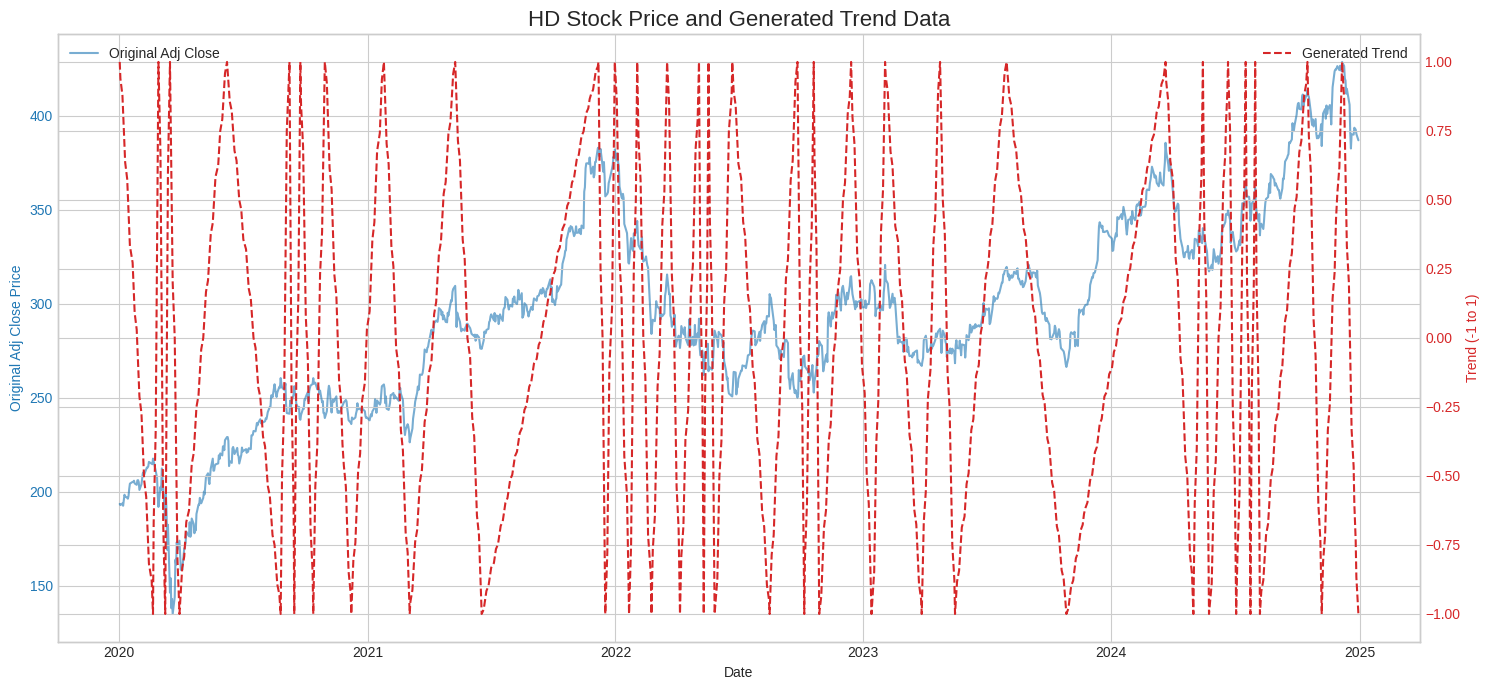

In [ ]:
# ✅ ZigZag 알고리즘으로 반전 지점 찾기
def _find_turning_points_zigzag(prices, P_threshold_pct, T_threshold_periods):
    if len(prices) < 2:
        return []

    turning_points = [0]
    last_pivot_idx = 0
    last_pivot_price = prices[0]
    trend = 0  # 1: 상승, -1: 하락

    # 현재 스윙의 잠재적 극단점(고점 또는 저점)
    candidate_pivot_idx = 0
    candidate_pivot_price = prices[0]

    for i in range(1, len(prices)):
        current_price = prices[i]
        price_diff_pct = abs((current_price - last_pivot_price) / last_pivot_price) * 100

        if trend == 0:  # 초기 추세 결정
            if price_diff_pct >= P_threshold_pct:
                trend = 1 if current_price > last_pivot_price else -1
                candidate_pivot_idx = i
                candidate_pivot_price = current_price

        elif trend == 1:  # 상승 추세 중
            if current_price > candidate_pivot_price:
                candidate_pivot_idx = i
                candidate_pivot_price = current_price
            # 고점 후보에서 P_threshold_pct 이상 하락 시, 고점 확정
            elif ((candidate_pivot_price - current_price) / candidate_pivot_price) * 100 >= P_threshold_pct:
                if (candidate_pivot_idx - last_pivot_idx) >= T_threshold_periods:
                    turning_points.append(candidate_pivot_idx)
                    last_pivot_idx, last_pivot_price = candidate_pivot_idx, candidate_pivot_price
                trend = -1
                candidate_pivot_idx, candidate_pivot_price = i, current_price

        elif trend == -1:  # 하락 추세 중
            if current_price < candidate_pivot_price:
                candidate_pivot_idx = i
                candidate_pivot_price = current_price
            # 저점 후보에서 P_threshold_pct 이상 상승 시, 저점 확정
            elif ((current_price - candidate_pivot_price) / candidate_pivot_price) * 100 >= P_threshold_pct:
                if (candidate_pivot_idx - last_pivot_idx) >= T_threshold_periods:
                    turning_points.append(candidate_pivot_idx)
                    last_pivot_idx, last_pivot_price = candidate_pivot_idx, candidate_pivot_price
                trend = 1
                candidate_pivot_idx, candidate_pivot_price = i, current_price

    # 마지막 지점을 추가하여 트렌드 라인이 끝나도록 함
    if turning_points[-1] != len(prices) - 1:
        turning_points.append(len(prices) - 1)

    return turning_points

# ✅ 트렌드 데이터 생성(P, T 값 5로 고정)
def generate_trend_data(df_stock, P_threshold_pct=5.0, T_threshold_periods=5):

    prices = df_stock['close'].values

    # 주요 반전 지점(turning points) 찾기
    tp_indices = _find_turning_points_zigzag(prices, P_threshold_pct, T_threshold_periods)

    if len(tp_indices) < 2:
        return pd.Series(np.zeros(len(df_stock)), index=df_stock.index, name='trend')

    # 반전 지점에 -1(저점) 또는 1(고점) 할당
    trend_values = pd.Series(index=df_stock.index, dtype=float)

    # 첫 번째 반전 지점의 유형 결정 (상승 시작인지 하락 시작인지)
    first_swing_price_change = prices[tp_indices[1]] - prices[tp_indices[0]]
    current_trend_val = 1.0 if first_swing_price_change > 0 else -1.0

    for idx in tp_indices:
        trend_values.loc[df_stock.index[idx]] = current_trend_val
        current_trend_val *= -1 # 다음 반전 지점은 부호 반전

    # 반전 지점 사이를 선형 보간
    trend_series = trend_values.interpolate(method='linear')
    trend_series = trend_series.bfill().ffill()

    return trend_series

# ================================= 메인 실행 로직 =================================
# ✅ 데이터 로드
df_all = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/stock/tictocstock.csv", parse_dates=['Date'])
df_all.columns = df_all.columns.str.strip().str.lower()
df_all['date'] = pd.to_datetime(df_all['date'])

processed_dfs = [] # 결과를 저장할 빈 리스트
tickers = df_all['ticker'].unique()

# ✅ 트렌드 데이터 만들기
for ticker in tickers:
    df_stock = df_all[df_all['ticker'] == ticker].copy().sort_values('date').set_index('date')
    df_stock['Close'] = df_stock['adj close'] # 조정 종가값 사용

    # 트렌드 데이터: P는 5% 이상 변동, T는  5일 이상 지속되는 추세만 인정
    trend_data = generate_trend_data(df_stock, P_threshold_pct=5.0, T_threshold_periods=5)
    df_stock['trend'] = trend_data
    processed_dfs.append(df_stock.reset_index()) # 인덱스를 다시 컬럼으로

df_final = pd.concat(processed_dfs, ignore_index=True) # 데이터프레임 합치기

# ✅ 최종 결과 CSV 파일로 저장
output_filename = 'tictocstock_trend.csv'
df_final.to_csv(output_filename, index=False)


# ================================= 결과 차트 시각화 =================================
# ✅ 결과 확인 (첫 번째 종목의 차트 시각화)
first_ticker = tickers[0]
df_sample = df_final[df_final['ticker'] == first_ticker].set_index('date')

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(15, 7))

# ✅ 첫 번째 Y축 (가격)
ax1.set_title(f'{first_ticker} Stock Price and Generated Trend Data', fontsize=16)
ax1.set_xlabel('Date')
ax1.set_ylabel('Original Adj Close Price', color='tab:blue')
ax1.plot(df_sample.index, df_sample['adj close'], color='tab:blue', alpha=0.6, label='Original Adj Close')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# ✅ 두 번째 Y축 (트렌드)
ax2 = ax1.twinx()
ax2.set_ylabel('Trend (-1 to 1)', color='tab:red')
ax2.plot(df_sample.index, df_sample['trend'], color='tab:red', linestyle='--', label='Generated Trend')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')
ax2.set_ylim(-1.1, 1.1)

fig.tight_layout()
plt.show()

# 기술 지표별 독립적으로 GA 파라미터 최적화

In [9]:
# ✅ Smoothed price
def smooth_price(df, p=5, t=5):
    df = df.copy()
    df['close'] = df['close'].ewm(span=p).mean().ewm(span=t).mean()
    return df

# ✅ GDC 기반 전략 (매도 시 1% 수수료)
class GDCStrategy(Strategy):
    def init(self):
        self.signal = self.data.signal
        self.last_signal = None

    def next(self):
        # ==================== 마지막날에 남은 주식 모두 매도하는 로직 추가 ====================
        if self.I == len(self.data) - 1:
              if self.position:
                  self.position.close()
              return

        current_signal = self.signal[-1]
        price = self.data.Close[-1]

        # ==================== 매수, 매도 시그널 바뀜 수정(-1 매수, 1 매도) ====================
        if self.position:
            if current_signal == -1 and self.position.is_short:
                self.position.close()
                self.buy()

            elif current_signal == 1 and self.position.is_long:
                self.position.close(size=self.position.size, reduce_only=False)
                self.sell()
        else:
            if current_signal == -1:
                self.buy()
            elif current_signal == 1:
                self.sell()

# ✅ SMA, EMA, MACD, RSI, Stochastic, ROC만 사용
def compute_indicators(df, params):
    # 어떤 형태의 df가 들어오든, 필요한 컬럼만 추출하여 중복 없는 깨끗한 데이터프레임을 새로 만듭니다.
    clean_df = pd.DataFrame({
        'open': df['open'].iloc[:, 0] if isinstance(df['open'], pd.DataFrame) else df['open'],
        'high': df['high'].iloc[:, 0] if isinstance(df['high'], pd.DataFrame) else df['high'],
        'low': df['low'].iloc[:, 0] if isinstance(df['low'], pd.DataFrame) else df['low'],
        'close': df['close'].iloc[:, 0] if isinstance(df['close'], pd.DataFrame) else df['close'],
        'volume': df['volume'].iloc[:, 0] if isinstance(df['volume'], pd.DataFrame) else df['volume'],
    }, index=df.index)
    df = smooth_price(clean_df)

    # SMA
    df['SMA'] = df['close'].rolling(int(params[0])).mean() - df['close'].rolling(int(params[1])).mean()

    # EMA
    df['EMA'] = df['close'].ewm(span=int(params[2]), adjust=False).mean() - df['close'].ewm(span=int(params[3]), adjust=False).mean()

    # MACD
    macd_fast = df['close'].ewm(span=int(params[4]), adjust=False).mean()
    macd_slow = df['close'].ewm(span=int(params[5]), adjust=False).mean()
    df['MACD'] = macd_fast - macd_slow
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()  # signal line

    # RSI
    delta = df['close'].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    ma_up = up.rolling(int(params[6])).mean()
    ma_down = down.rolling(int(params[6])).mean()
    rs = ma_up / (ma_down + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    # Stochastic: %K, %D
    low_min = df['low'].rolling(int(params[7])).min()
    high_max = df['high'].rolling(int(params[7])).max()
    df['Stoch_K'] = (df['close'] - low_min) / (high_max - low_min + 1e-10) * 100
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()

    # ROC
    df['ROC'] = df['close'].pct_change(periods=int(params[8])) * 100

    df = df.dropna().copy()
    return df

# ✅ 신호 생성 함수 - 지정된 단일 지표에 대한 매매 신호(-1, 0, 1) 생성하도록 변경
def generate_single_indicator_signal(df, indicator_name):
    signals = pd.Series(index=df.index, data=0) # 0으로 초기화

    if indicator_name == 'SMA':
        signals[df['SMA'] > 0] = -1 # 단기 > 장기 (매수)
        signals[df['SMA'] < 0] = 1  # 단기 < 장기 (매도)
    elif indicator_name == 'EMA':
        signals[df['EMA'] > 0] = -1
        signals[df['EMA'] < 0] = 1
    elif indicator_name == 'MACD':
        signals[df['MACD'] > df['MACD_Signal']] = -1 # MACD > Signal (매수)
        signals[df['MACD'] < df['MACD_Signal']] = 1  # MACD < Signal (매도)
    elif indicator_name == 'RSI':
        signals[df['RSI'] < 30] = -1 # 과매도 (매수)
        signals[df['RSI'] > 70] = 1  # 과매수 (매도)
    elif indicator_name == 'Stochastic':
        signals[df['Stoch_K'] > df['Stoch_D']] = -1 # %K > %D (매수)
        signals[df['Stoch_K'] < df['Stoch_D']] = 1  # %K < %D (매도)
    elif indicator_name == 'ROC':
        signals[df['ROC'] > 0] = -1 # 상승 추세 (매수)
        signals[df['ROC'] < 0] = 1  # 하락 추세 (매도)

    return signals.values

# ✅ 커스텀 수수료 (매도 시에만 1% 적용)
def safe_commission(trade, order):
    try:
        return 0.01 * trade.value if hasattr(trade, 'is_short') and (trade.is_short or trade.side == 'sell') else 0
    except Exception:
        return 0

# ✅ 백테스트 함수
def backtest(df, signal):
    df_bt = df.copy()
    df_bt['signal'] = signal
    df_bt = df_bt[['open', 'high', 'low', 'close', 'volume', 'signal']].dropna()
    df_bt.rename(columns={'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'}, inplace=True)
    df_bt.index.name = 'Date'
    bt = Backtest(
    df_bt,
    GDCStrategy,
    cash=100_000,
    commission=safe_commission,
    exclusive_orders=True
    )

    stats = bt.run()
    return stats['Return [%]'] / 100, stats['Max. Drawdown [%]'] / 100, stats['Sharpe Ratio']


📘 학습 데이터 기간: 2020-01-02 ~ 2024-06-28
📙 백테스트 데이터 기간: 2024-07-01 ~ 2024-12-30

--- SMA 최적화 진행 ---
✅ SMA 최적 파라미터 : [44, 59]
✅ 최적 피트니스 값 : 24.110728588360058

--- EMA 최적화 진행 ---
✅ EMA 최적 파라미터 : [46, 56]
✅ 최적 피트니스 값 : 23.98952087727986

--- MACD 최적화 진행 ---
✅ MACD 최적 파라미터 : [18, 57]
✅ 최적 피트니스 값 : -22.833939926333855

--- RSI 최적화 진행 ---
✅ RSI 최적 파라미터 : [26]
✅ 최적 피트니스 값 : 57.47964543600145

--- Stochastic 최적화 진행 ---
✅ Stochastic 최적 파라미터 : [15]
✅ 최적 피트니스 값 : -6.457829961591987

--- ROC 최적화 진행 ---
✅ ROC 최적 파라미터 : [16]
✅ 최적 피트니스 값 : -25.735126712906094

--- 📊 GA 최적화 과정 피트니스 시각화 ---


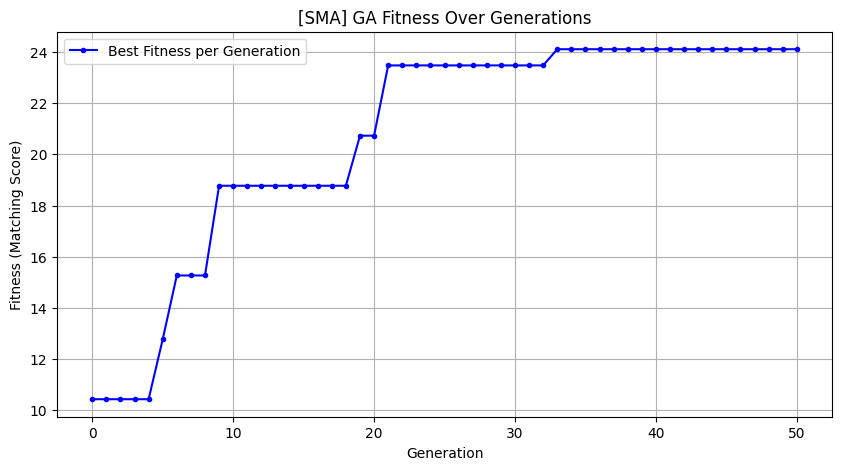

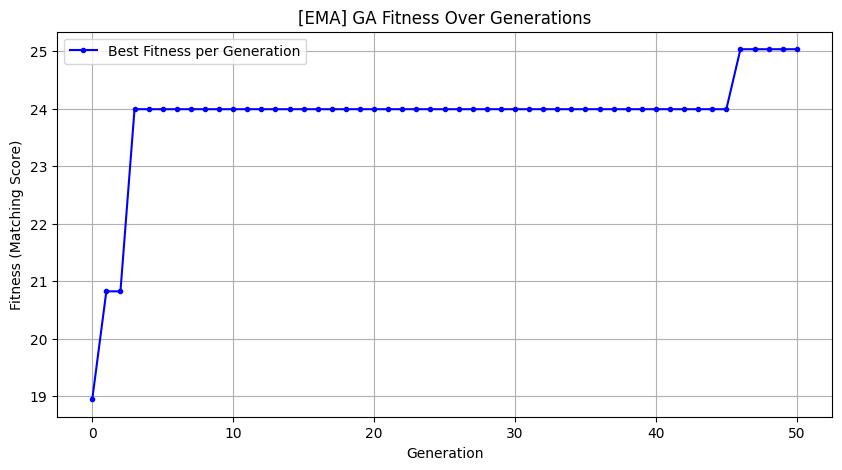

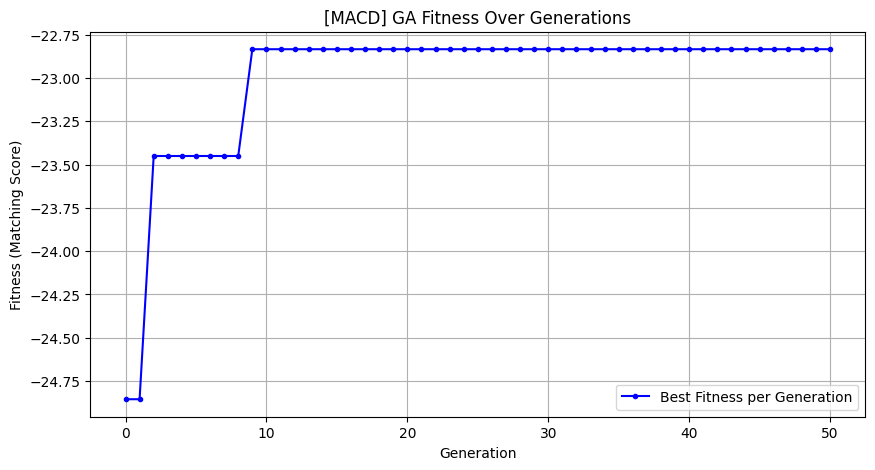

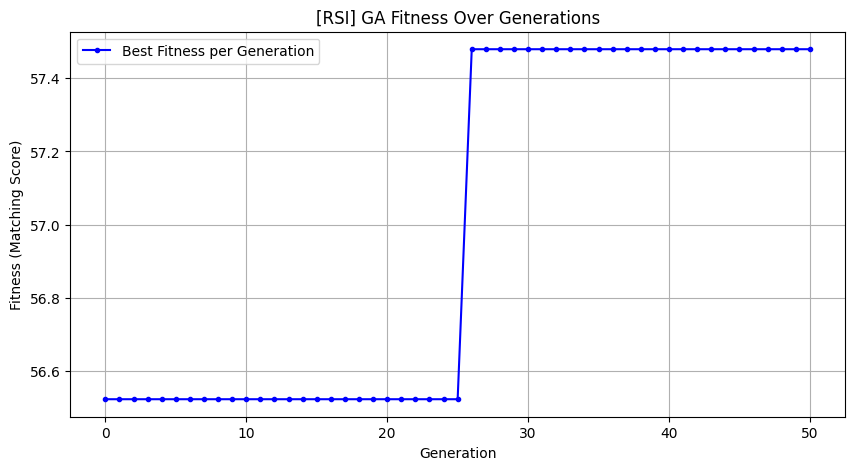

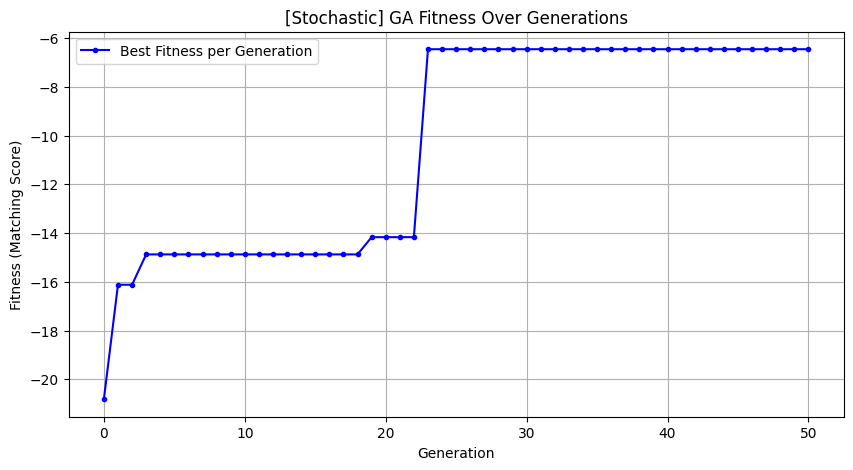

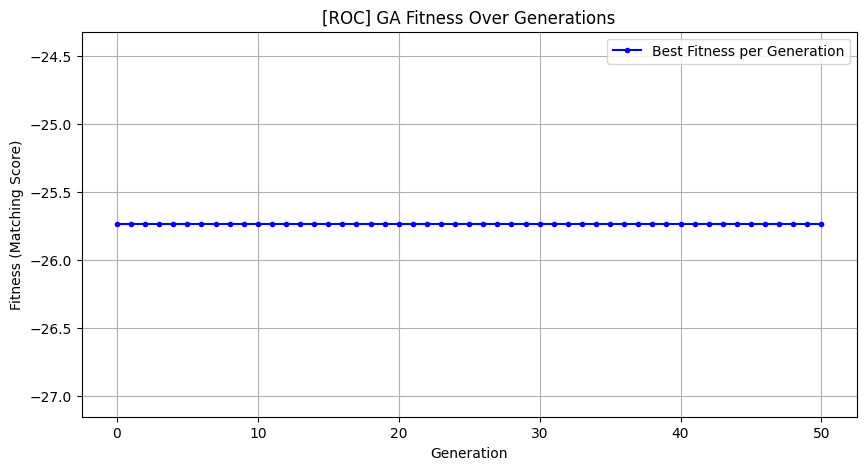


===================✅ 최종 최적 파라미터 출력===================
{'SMA': [44, 59], 'EMA': [46, 56], 'MACD': [18, 57], 'RSI': [26], 'Stochastic': [15], 'ROC': [16]}


In [10]:
# ================================= 메인 실행 로직 =================================
# ✅ 데이터 로드
df_all = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/stock/tictocstock_trend.csv", parse_dates=['date'])
df_all.columns = df_all.columns.str.strip().str.lower()
#df_all = df_all[['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]
df_all.sort_values(['ticker', 'date'], inplace=True)

# ✅ SBUX 데이터 불러오기, 학습/테스트 데이터 생성
df = df_all[df_all['ticker'] == 'SBUX'].set_index('date').copy().ffill()
df['close'] = df['adj close'] # 조정 종가값을 close 컬럼으로 사용하도록 설정 !!!

split_date = df.index.max() - pd.DateOffset(months=6)
df_train = df[df.index < split_date].copy()
df_test = df[df.index >= split_date].copy()

print("📘 학습 데이터 기간:", df_train.index.min().date(), "~", df_train.index.max().date())
print("📙 백테스트 데이터 기간:", df_test.index.min().date(), "~", df_test.index.max().date())


# ✅ 각 지표별 유전자 범위 설정
indicator_configs = {
    'SMA':        {'param_indices': [0, 1], 'gene_space': [{'low': 5, 'high': 50}, {'low': 10, 'high': 60}]},
    'EMA':        {'param_indices': [2, 3], 'gene_space': [{'low': 5, 'high': 50}, {'low': 10, 'high': 60}]},
    'MACD':       {'param_indices': [4, 5], 'gene_space': [{'low': 5, 'high': 25}, {'low': 26, 'high': 60}]},
    'RSI':        {'param_indices': [6],    'gene_space': [{'low': 5, 'high': 30}]},
    'Stochastic': {'param_indices': [7],    'gene_space': [{'low': 5, 'high': 40}]},
    'ROC':        {'param_indices': [8],    'gene_space': [{'low': 5, 'high': 30}]},
}

# ✅ 타겟 데이터로 트렌드 데이터 사용
Y_target_trend = df_train['trend'].values

all_best_params = {} # 최적화된 파라미터 저장
ga_instances = {}

# ✅ GA 최적화 과정의 피트니스 변화 시각화용 함수
def plot_ga_fitness(ga_instance, indicator_name):
    plt.figure(figsize=(10, 5))
    plt.plot(ga_instance.best_solutions_fitness, label='Best Fitness per Generation', color='blue', marker='.')
    plt.title(f'[{indicator_name}] GA Fitness Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Fitness (Matching Score)')
    plt.grid(True)
    plt.legend()
    plt.show()

# ✅ 각 지표별로  GA를 반복 실행
for indicator_name, config in indicator_configs.items():
    print(f"\n--- {indicator_name} 최적화 진행 ---")

    # 피트니스 함수
    def fitness_func(ga_instance, solution, solution_idx):
        try:
            current_params = [10] * 9 # 기본값으로 초기화 (사용되지 않는 값)
            for i, p_idx in enumerate(config['param_indices']):
                current_params[p_idx] = solution[i]

            # 파라미터 조건 확인 (단기 < 장기)
            if 'SMA' in indicator_name and not (solution[0] < solution[1]): return -np.inf
            if 'EMA' in indicator_name and not (solution[0] < solution[1]): return -np.inf
            if 'MACD' in indicator_name and not (solution[0] < solution[1]): return -np.inf

            # 지표 계산 및 단일 시그널 생성
            df_ind = compute_indicators(df_train, current_params)
            # compute_indicators가 NaN을 제거하므로, 타겟 데이터도 길이에 맞게 잘라줘야 함
            aligned_Y_target = Y_target_trend[-len(df_ind):]

            signal = generate_single_indicator_signal(df_ind, indicator_name)

            # 지표 시그널과 타겟 트렌드와의 일치도 확인
            # (매수 -1, 상승 1) -> 곱하면 -1 / (매도 1, 하락 -1) -> 곱하면 -1
            # 즉, 시그널 * 트렌드 값이 음수일 때 방향이 일치함. 일치하면 +1, 반대면 -1
            matching_score = -np.sum(signal * aligned_Y_target)
            return matching_score

        except Exception as e:
            print(f"Error in fitness_func for '{indicator_name}' with solution {solution}: {e}")
            return -np.inf

    # GA 인스턴스 생성
    ga = pygad.GA(
        num_generations=50,
        num_parents_mating=20,
        fitness_func=fitness_func,
        sol_per_pop=20,
        num_genes=len(config['gene_space']), # 현재 지표의 파라미터 개수
        gene_space=config['gene_space'],      # 현재 지표의 유전자 범위
        gene_type=float,
        mutation_type="random",
        mutation_num_genes=1,
    )

    ga.run()
    best_solution, best_fitness, _ = ga.best_solution()
    all_best_params[indicator_name] = [int(round(g)) for g in best_solution]
    ga_instances[indicator_name] = ga # GA 인스턴스 저장

    print(f"✅ {indicator_name} 최적 파라미터 : {all_best_params[indicator_name]}")
    print(f"✅ 최적 피트니스 값 : {best_fitness}")

print("\n--- 📊 GA 최적화 과정 피트니스 시각화 ---")
for indicator_name, ga_instance in ga_instances.items():
    plot_ga_fitness(ga_instance, indicator_name)

print("\n===================✅ 최종 최적 파라미터 출력===================")
print(all_best_params)

# 결과 시각화

Backtest.run:   0%|          | 0/68 [00:00<?, ?bar/s]

  - 수익률: -4.73%
  - MDD: -10.15%
  - Sharpe Ratio: -2.754


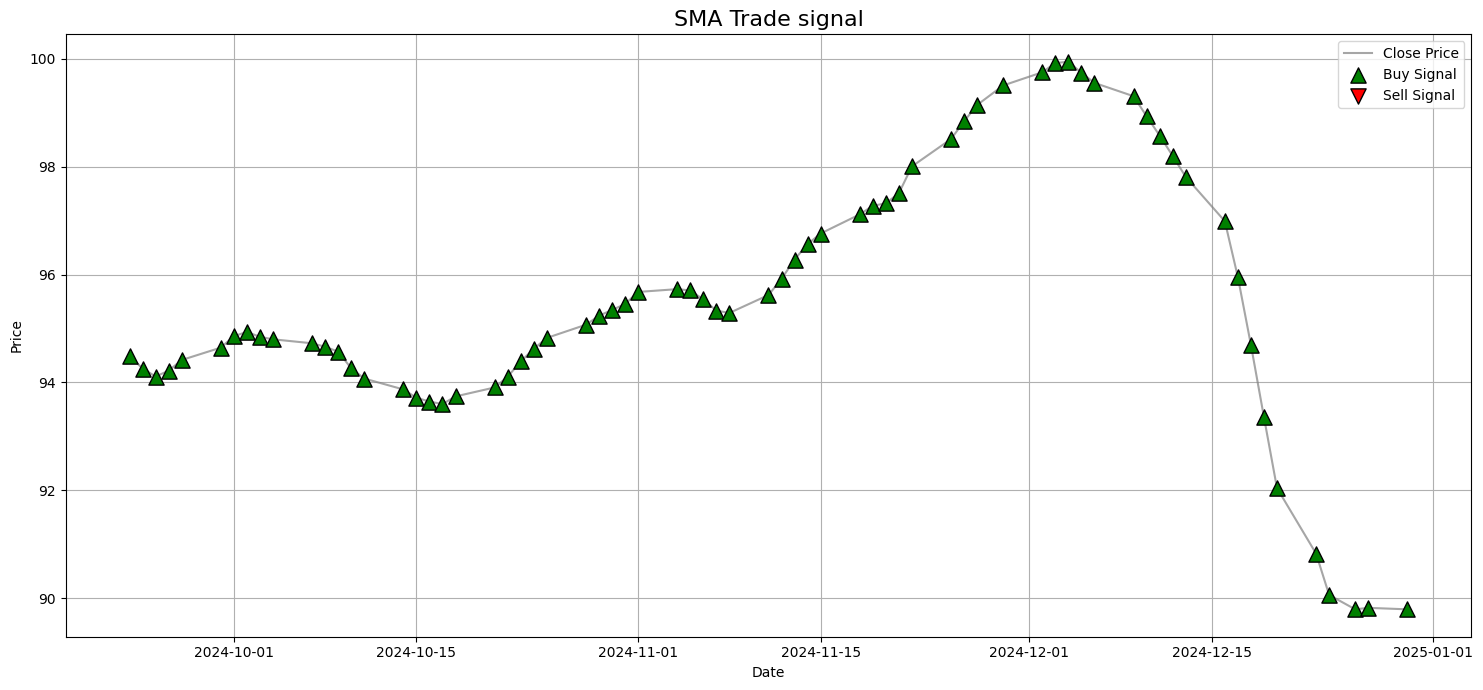

Backtest.run:   0%|          | 0/107 [00:00<?, ?bar/s]

  - 수익률: 12.88%
  - MDD: -10.16%
  - Sharpe Ratio: 1.396


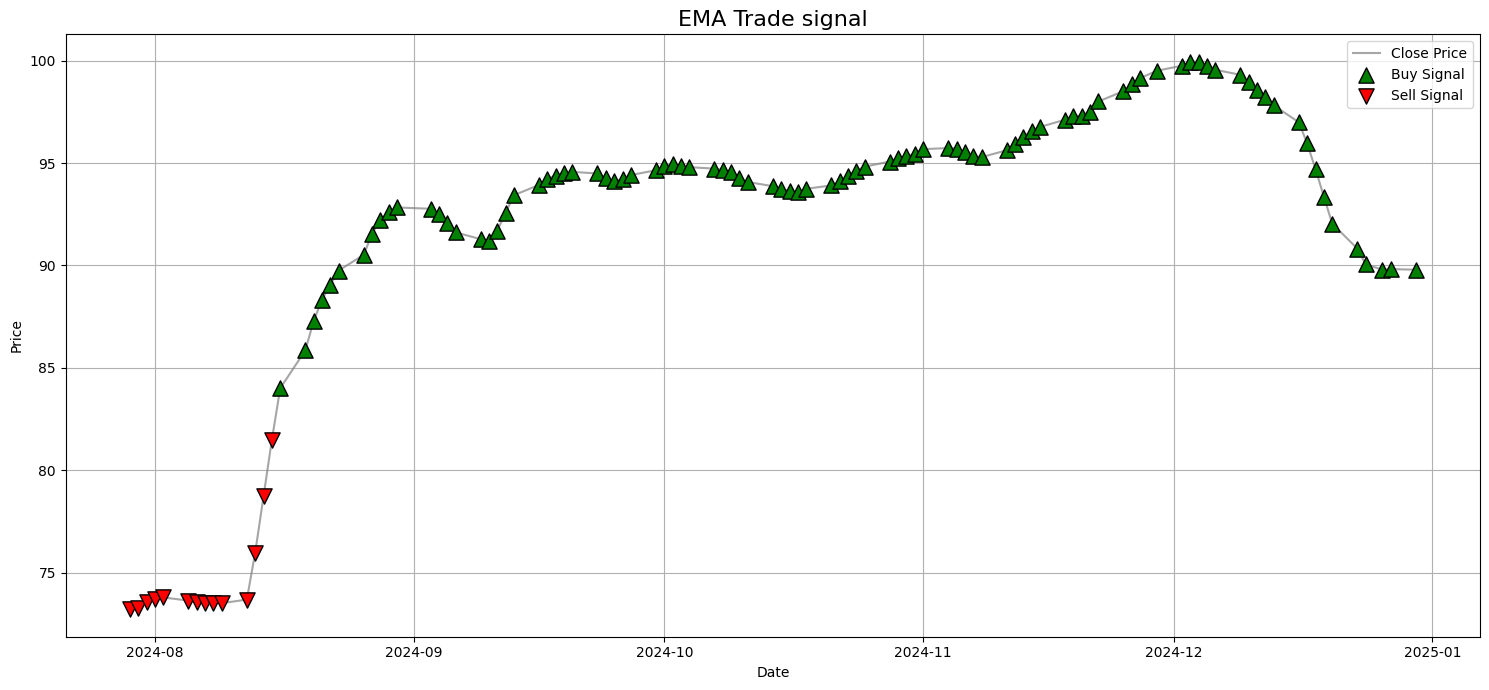

Backtest.run:   0%|          | 0/107 [00:00<?, ?bar/s]

  - 수익률: -12.88%
  - MDD: -30.88%
  - Sharpe Ratio: -1.989


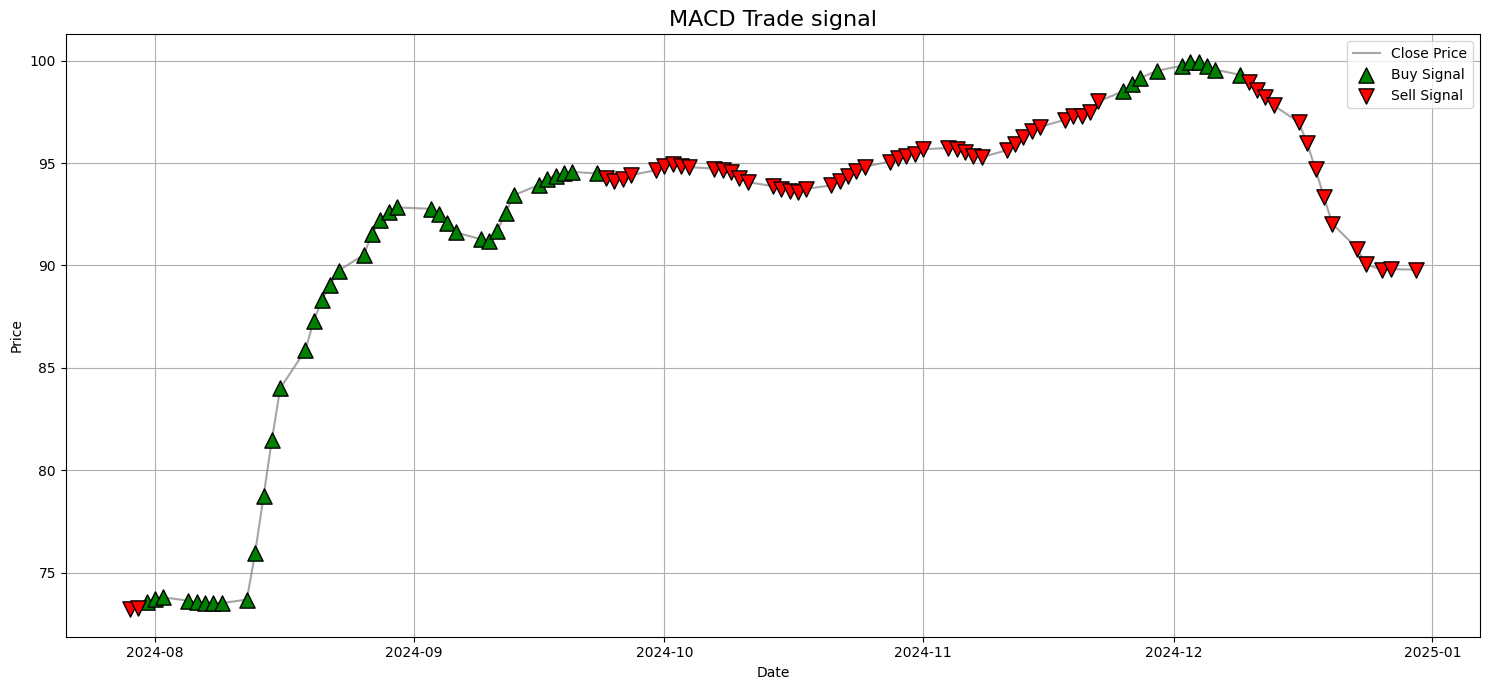

Backtest.run:   0%|          | 0/100 [00:00<?, ?bar/s]

  - 수익률: 18.69%
  - MDD: -10.15%
  - Sharpe Ratio: 2.439


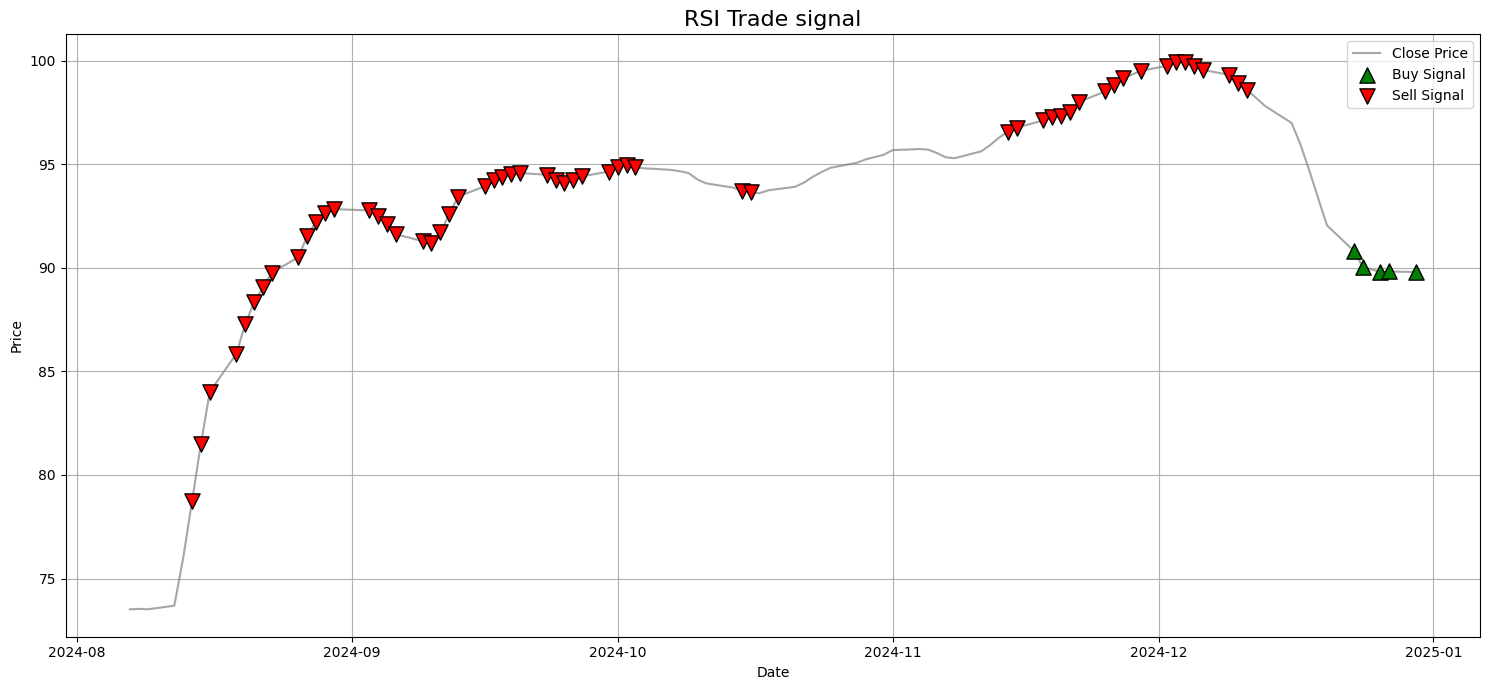

Backtest.run:   0%|          | 0/107 [00:00<?, ?bar/s]

  - 수익률: 12.88%
  - MDD: -10.16%
  - Sharpe Ratio: 1.396


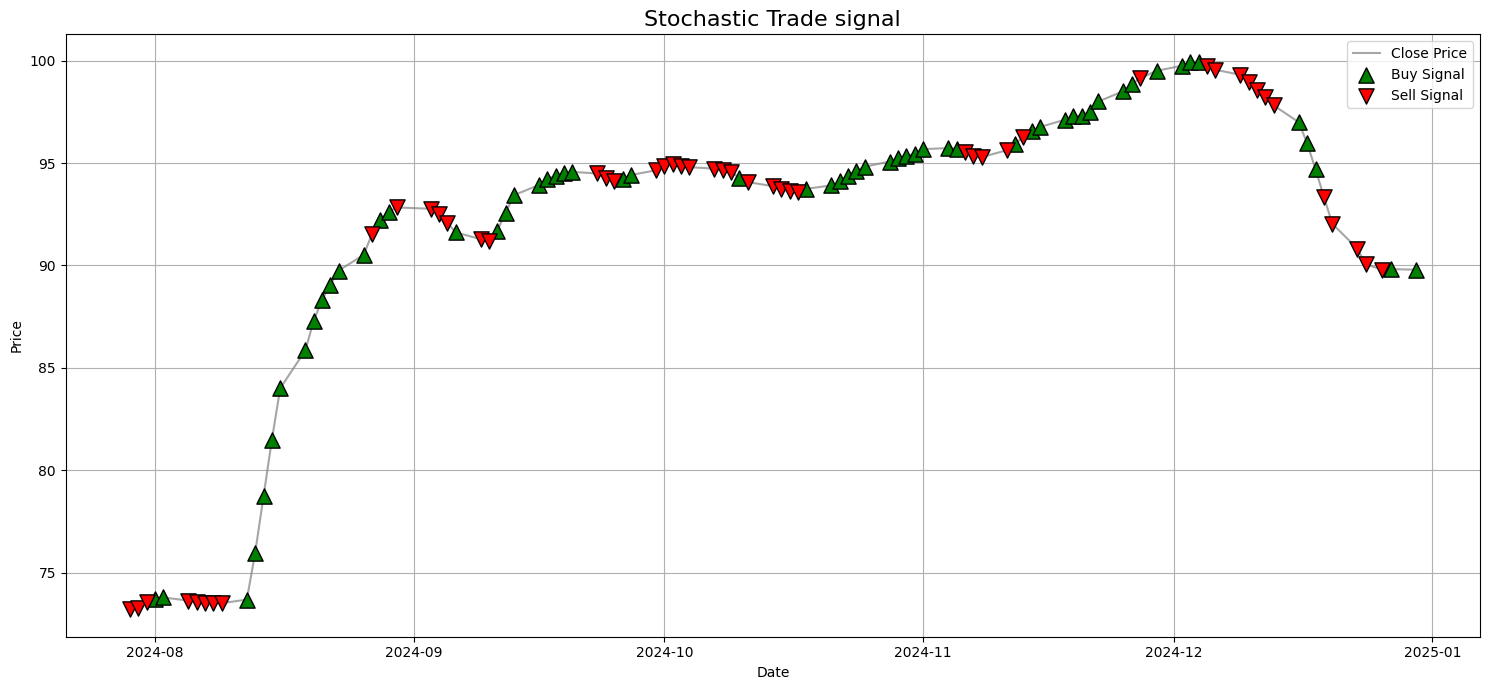

Backtest.run:   0%|          | 0/107 [00:00<?, ?bar/s]

  - 수익률: -12.88%
  - MDD: -30.88%
  - Sharpe Ratio: -1.989


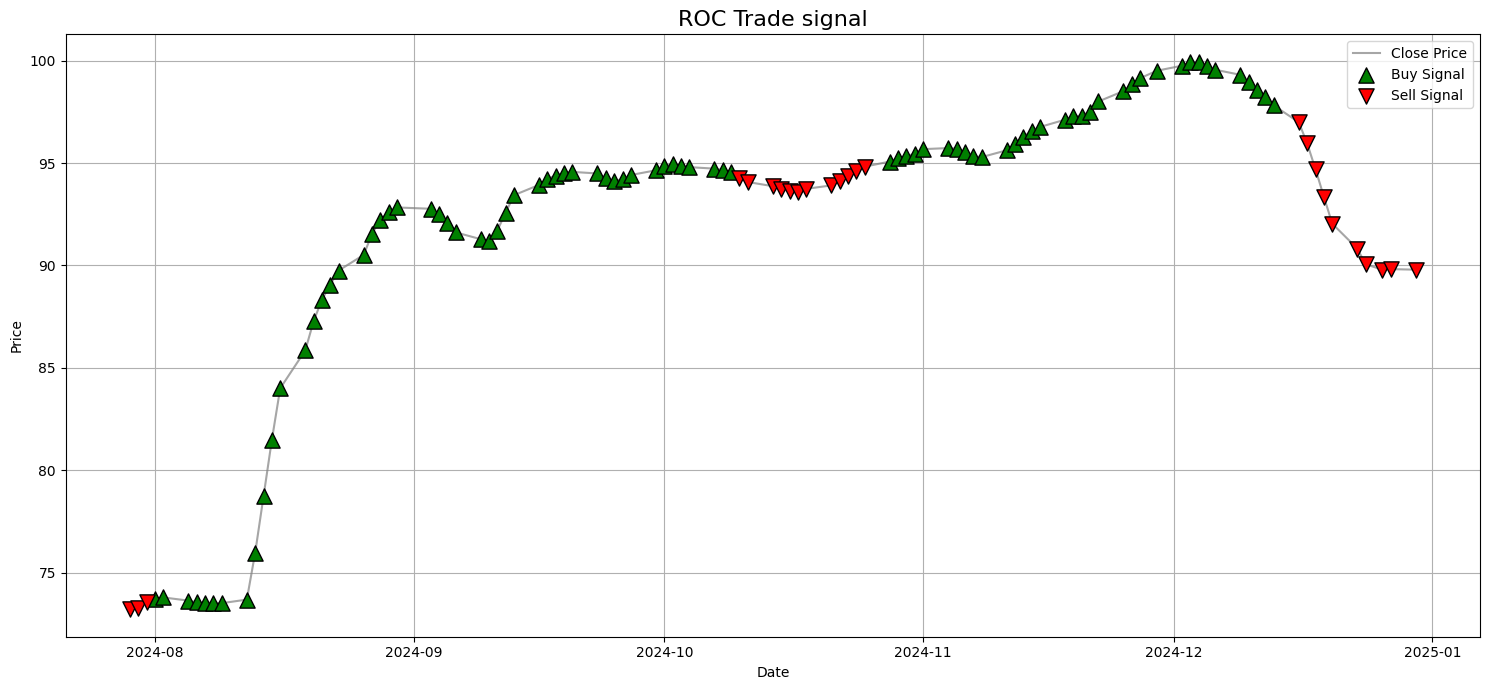


=================== 📝 백테스트 결과 요약 ===================
            Profit [%]  Max. Drawdown [%]  Sharpe Ratio
Indicator                                              
SMA              -4.73             -10.15        -2.754
EMA              12.88             -10.16         1.396
MACD            -12.88             -30.88        -1.989
RSI              18.69             -10.15         2.439
Stochastic       12.88             -10.16         1.396
ROC             -12.88             -30.88        -1.989

=================== 📈 평균 성능 ===================
평균 수익률: 2.33%
평균 MDD: -17.06%
평균 Sharpe Ratio: -0.250


In [11]:
# ✅ 최적화된 각 지표별로 테스트 데이터 백테스트 실행 ==============================
results = []
base_params = [10, 20, 10, 20, 12, 26, 14, 14, 10] # 기본값

for indicator_name, best_params_for_indicator in all_best_params.items():
    current_test_params = base_params.copy()
    config = indicator_configs[indicator_name]
    for i, p_idx in enumerate(config['param_indices']):
        current_test_params[p_idx] = best_params_for_indicator[i]

    df_test_ind = compute_indicators(df_test, current_test_params)
    signal_test = generate_single_indicator_signal(df_test_ind, indicator_name)
    profit, mdd, sharpe = backtest(df_test_ind, signal_test)

    results.append({
        'Indicator': indicator_name,
        'Profit [%]': round(profit * 100, 2),
        'Max. Drawdown [%]': round(mdd * 100, 2),
        'Sharpe Ratio': round(sharpe, 3)
    })

    print(f"  - 수익률: {results[-1]['Profit [%]']}%")
    print(f"  - MDD: {results[-1]['Max. Drawdown [%]']}%")
    print(f"  - Sharpe Ratio: {results[-1]['Sharpe Ratio']}")

    # 매매 신호 시각화 로직 추가
    plt.figure(figsize=(15, 7))
    plt.plot(df_test_ind.index, df_test_ind['close'], label='Close Price', color='gray', alpha=0.7)

    # backtesting 라이브러리의 신호 규칙(매수 1, 매도 -1)에 맞춰서 시각화
    buy_signals = df_test_ind[signal_test == -1]
    sell_signals = df_test_ind[signal_test == 1]

    plt.scatter(buy_signals.index, buy_signals['close'], marker='^', color='green', label='Buy Signal', s=120, zorder=5, edgecolors='black')
    plt.scatter(sell_signals.index, sell_signals['close'], marker='v', color='red', label='Sell Signal', s=120, zorder=5, edgecolors='black')

    plt.title(f"{indicator_name} Trade signal", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


results_df = pd.DataFrame(results).set_index('Indicator')
average_results = results_df.mean()

print("\n=================== 📝 백테스트 결과 요약 ===================")
print(results_df)

print("\n=================== 📈 평균 성능 ===================")
print(f"평균 수익률: {average_results['Profit [%]']:.2f}%")
print(f"평균 MDD: {average_results['Max. Drawdown [%]']:.2f}%")
print(f"평균 Sharpe Ratio: {average_results['Sharpe Ratio']:.3f}")

# ESN 모델 학습

In [17]:
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import nrmse, rsquare

indicator_configs = {
    'SMA':        {'param_indices': [0, 1]}, 'EMA':  {'param_indices': [2, 3]},
    'MACD':       {'param_indices': [4, 5]}, 'RSI':  {'param_indices': [6]},
    'Stochastic': {'param_indices': [7]}, 'ROC':  {'param_indices': [8]},
}

# ✅ 데이터 로드
df_all = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/stock/tictocstock_trend.csv", parse_dates=['date'])
df_all.columns = df_all.columns.str.strip().str.lower()
if 'adj close' in df_all.columns and 'close' in df_all.columns:
    df_all.drop('close', axis=1, inplace=True)
    df_all.rename(columns={'adj close': 'close'}, inplace=True)

print(df_all.columns)
df_all.sort_values(['ticker', 'date'], inplace=True)

df_ticker = df_all[df_all['ticker'] == 'SBUX'].set_index('date').copy().ffill()

df_esn_input = pd.DataFrame(index=df_ticker.index) # ESN 입력을 담을 데이터프레임

# ✅ 입력 데이터(X) 만들기 - 지표별 최적 파라미터로 시그널 생성
for indicator_name, best_params in all_best_params.items():
    current_params = base_params.copy()
    config = indicator_configs[indicator_name]
    for i, p_idx in enumerate(config['param_indices']):
        current_params[p_idx] = best_params[i]

    df_with_indicator = compute_indicators(df_ticker, current_params)
    signals = generate_single_indicator_signal(df_with_indicator, indicator_name)

    df_esn_input[indicator_name] = pd.Series(signals, index=df_with_indicator.index)

# 타겟 데이터(Y)와 입력 데이터(X)의 날짜를 맞추고 결측치 제거
df_final_esn_data = df_ticker.join(df_esn_input).dropna()

# ✅ 최종 X, Y 데이터 정의
feature_columns = list(all_best_params.keys()) # ['SMA', 'EMA', ...]
X = df_final_esn_data[feature_columns].values
Y = df_final_esn_data[['trend']].values

# ✅ 훈련/테스트 데이터 분할 (예: 80% 훈련, 20% 테스트)
split_ratio = 0.8
split_point = int(len(X) * split_ratio)

X_train, Y_train = X[:split_point], Y[:split_point]
X_test, Y_test = X[split_point:], Y[split_point:]
print(f"훈련 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'trend'], dtype='object')
훈련 데이터: (959, 6), 테스트 데이터: (240, 6)


Running Ridge-9: 100%|██████████| 240/240 [00:00<00:00, 15121.19it/s]


테스트 데이터 성능:
  - NRMSE (정규화 평균 제곱근 오차): 0.6259
  - R-square (결정 계수): -3.6620


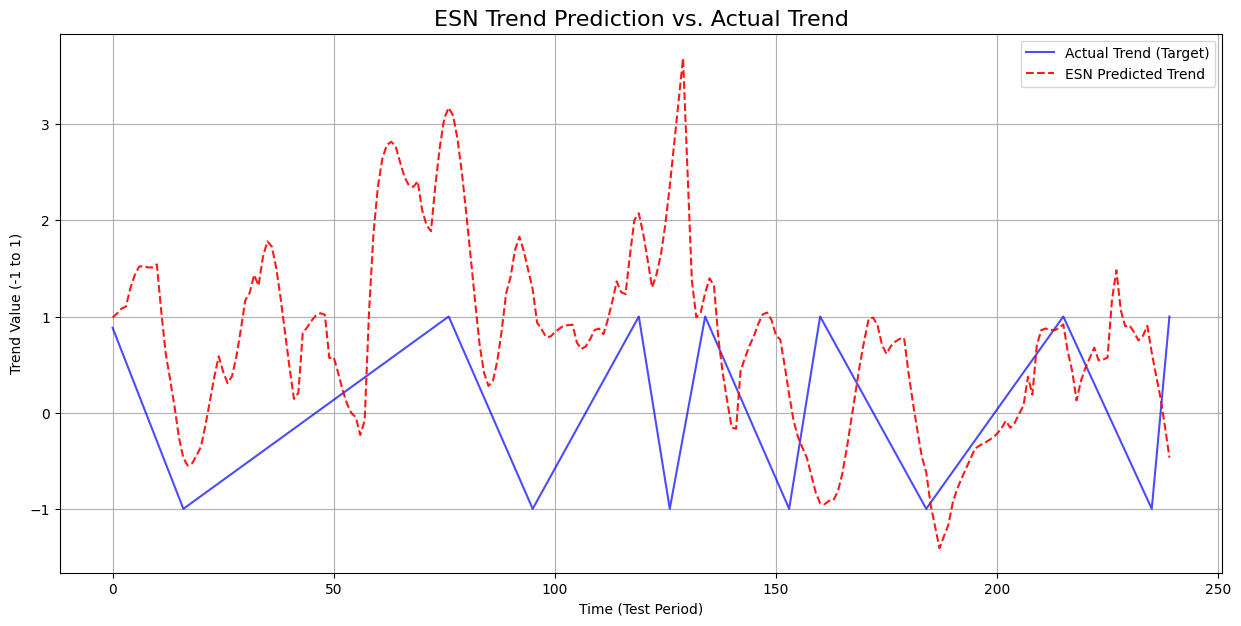


ESN 예측값을 최종 매매 시그널로 변환한 예시 (상위 10개):
  - 예측된 트렌드 값: ['0.99', '1.03', '1.08', '1.10', '1.29', '1.43', '1.52', '1.52', '1.51', '1.51']
  - 최종 매매 시그널: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [27]:
# ======================== ReservoirPy를 이용한 ESN 모델 구축 및 학습 ========================
# ✅ 하이퍼파라미터 설정 (튜닝 필요)
reservoir_units = 200      # 리저버 뉴런 개수 - 값이 클수록 더 복잡하고 미묘한 패턴 학습 가능함
leak_rate = 0.2            # 리킹 비율 (메모리 조절) - 값이 클수록 뉴런 상태가 빠르게 변함. 최신 입력에 민감
spectral_radius = 1.2      # 스펙트럼 반지름 - 1에 가깝게 할수록 장기 메모리 유지, 장기적 추세 학습
input_scaling = 1.0        # 입력 가중치 스케일
ridge_param = 1e-5         # 리드아웃의 정규화 강도 - 과적합 방지용

# ✅ ESN 노드 생성
reservoir = Reservoir(units=reservoir_units, lr=leak_rate, sr=spectral_radius, input_scaling=input_scaling)
readout = Ridge(ridge=ridge_param)

# ✅ 훈련: 리저버 상태 수집 후 리드아웃 학습
reservoir_states_train = reservoir.run(X_train)
readout.fit(reservoir_states_train, Y_train)

# ✅ 예측
reservoir_states_test = reservoir.run(X_test)
Y_predicted = readout.run(reservoir_states_test)

# ============================== 결과 평가 및 시각화 ==============================
# ✅ 성능 지표 계산
test_nrmse_score = nrmse(Y_test, Y_predicted)
test_rsquare_score = rsquare(Y_test, Y_predicted)

print(f"테스트 데이터 성능:")
print(f"  - NRMSE (정규화 평균 제곱근 오차): {test_nrmse_score:.4f}")
print(f"  - R-square (결정 계수): {test_rsquare_score:.4f}")

# ✅ 시각화
plt.figure(figsize=(15, 7))
plt.title("ESN Trend Prediction vs. Actual Trend", fontsize=16)
plt.xlabel("Time (Test Period)")
plt.ylabel("Trend Value (-1 to 1)")
plt.plot(Y_test, label="Actual Trend (Target)", color='blue', alpha=0.7)
plt.plot(Y_predicted, label="ESN Predicted Trend", color='red', linestyle='--', alpha=0.9)
plt.legend()
plt.grid(True)
plt.show()

# ✅ ESN 예측 결과를 최종 매매 시그널로 변환
trading_threshold = 0.3
final_signals = np.zeros_like(Y_predicted)
final_signals[Y_predicted < -trading_threshold] = -1 # 매수 신호 (논문에서는 -1이 매수)
final_signals[Y_predicted > trading_threshold] = 1  # 매도 신호

print("\nESN 예측값을 최종 매매 시그널로 변환한 예시 (상위 10개):")
print(f"  - 예측된 트렌드 값: {[f'{val:.2f}' for val in Y_predicted[:10].flatten()]}")
print(f"  - 최종 매매 시그널: {final_signals[:10].flatten()}")


In [19]:
# ✅ 백테스트에 사용할 데이터 준비
df_for_backtest = df_final_esn_data.iloc[split_point:].copy()
esn_final_signals = final_signals
esn_signals_1d = esn_final_signals.flatten() # 2차원 시그널을 1차원으로 변환

# ✅ 백테스트 실행
try:
    profit, mdd, sharpe = backtest(df_for_backtest, esn_signals_1d)

    print("\n📊 ESN 결과 시그널 백테스트 결과")
    print(f"  - 최종 수익률 (Return): {profit * 100:.2f}%")
    print(f"  - 최대 낙폭 (Max. Drawdown): {mdd * 100:.2f}%")
    print(f"  - 샤프 지수 (Sharpe Ratio): {sharpe:.3f}")

except Exception as e:
    print(f"에러 발생 {e}")


Backtest.run:   0%|          | 0/239 [00:00<?, ?bar/s]


📊 ESN 결과 시그널 백테스트 결과
  - 최종 수익률 (Return): 0.00%
  - 최대 낙폭 (Max. Drawdown): -0.00%
  - 샤프 지수 (Sharpe Ratio): nan
